In [1]:
from simulations.envelope import a_d_envelope, TIME_END, TIME_START

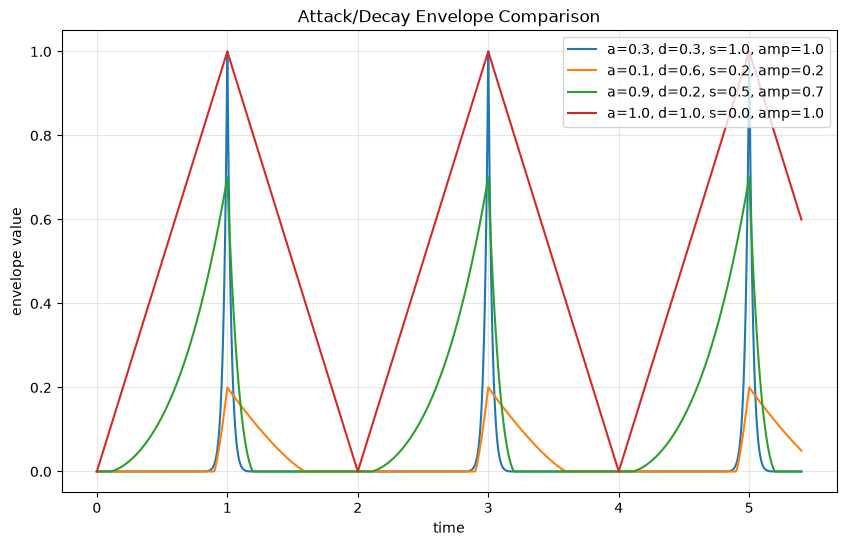

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis: 0 to TIME_END*2.7
t_max = TIME_END * 2.7
times = np.linspace(TIME_START, t_max, 1000)

# Define a few parameter combinations to compare
combos = [
    {"attack": 0.3, "decay": 0.3, "shape": 1.0, "amplitude": 1.0},
    {"attack": 0.1, "decay": 0.6, "shape": 0.2, "amplitude": 0.2},
    {"attack": 0.9, "decay": 0.2, "shape": 0.5, "amplitude": 0.7},
    {"attack": 1.0, "decay": 1.0, "shape": 0.0, "amplitude": 1.0},
]

plt.figure(figsize=(10, 6))

for combo in combos:
    # a_d_envelope asserts time <= TIME_END, so clip times beyond that to TIME_END
    # (the function returns 0 there anyway since time > TIME_MIDPOINT + decay)
    values = [
        a_d_envelope(combo["attack"], combo["decay"], combo["shape"], combo["amplitude"], t % TIME_END)
        for t in times
    ]
    label = f"a={combo['attack']}, d={combo['decay']}, s={combo['shape']}, amp={combo['amplitude']}"
    plt.plot(times, values, label=label)

plt.xlabel("time")
plt.ylabel("envelope value")
plt.title("Attack/Decay Envelope Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()